In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import re
import string


In [80]:
data_fake=pd.read_csv('Fake.csv')
data_true=pd.read_csv('True.csv')

In [81]:
from google.colab import drive
drive.mount('drive')

Drive already mounted at drive; to attempt to forcibly remount, call drive.mount("drive", force_remount=True).


In [82]:
data_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [83]:
data_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [84]:
data_fake["class"]=0
data_true['class']=1

In [85]:
data_fake.shape,data_true.shape

((23481, 5), (21417, 5))

In [86]:
data_fake_manual_testing = data_fake.tail(10)
data_fake.drop(data_fake_manual_testing.index, axis=0, inplace=True)

data_true_manual_testing = data_true.tail(10)
data_true.drop(data_true_manual_testing.index, axis=0, inplace=True)

In [87]:
data_merge = pd.concat([data_fake, data_true], axis=0)
display(data_merge.head())

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


Next, we'll drop columns that are not relevant for the classification task, such as 'title', 'subject', and 'date'. The 'text' column will be our primary feature.

In [88]:
data = data_merge.drop(['title', 'subject', 'date'], axis=1)
display(data.head())

,text,class
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [89]:
data_fake.shape,data_true.shape

((23471, 5), (21407, 5))

In [90]:
data_fake_manual_testing.loc[:, 'class'] = 0
data_true_manual_testing.loc[:, 'class'] = 1

In [91]:
data_fake_manual_testing.head(10)

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",0


In [92]:
data_merge = pd.concat([data_fake, data_true], axis =0 )
data_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [93]:
data_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [94]:
data = data_merge.drop(['title', 'subject','date'], axis = 1)

In [95]:
data.isnull().sum()

,0
text,0
class,0


In [96]:
data= data.sample(frac=1)

In [97]:
data.head()

,text,class
15902,WASHINGTON (Reuters) - A rare high-level defec...,1
8200,WASHINGTON (Reuters) - Leaders in the U.S. Con...,1
14208,"Unfortunately, in this day and age, it doesn t...",0
6154,WASHINGTON (Reuters) - President Donald Trump ...,1
1053,WASHINGTON (Reuters) - Top Democrats in the U....,1


### Class Distribution
Let's visualize the distribution of `Fake` vs. `True` news in our combined dataset.

/tmp/ipykernel_3034/919525110.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=data, palette='viridis')


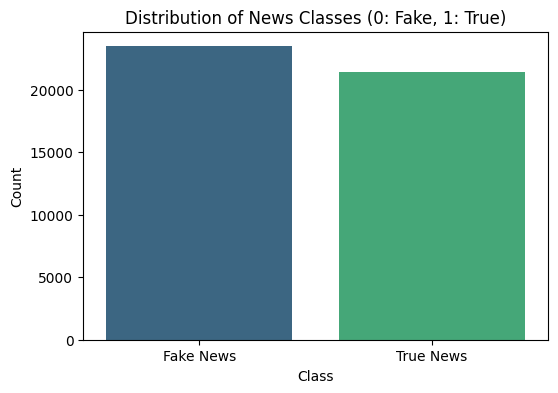

In [98]:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=data, palette='viridis')
plt.title('Distribution of News Classes (0: Fake, 1: True)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake News', 'True News'])
plt.show()

In [99]:
data.reset_index(inplace= True)
data.drop(['index'], axis=1,inplace=True)

In [100]:
data.columns

Index(['text', 'class'], dtype='object')

In [101]:
data.head()

,text,class
0,WASHINGTON (Reuters) - A rare high-level defec...,1
1,WASHINGTON (Reuters) - Leaders in the U.S. Con...,1
2,"Unfortunately, in this day and age, it doesn t...",0
3,WASHINGTON (Reuters) - President Donald Trump ...,1
4,WASHINGTON (Reuters) - Top Democrats in the U....,1


In [102]:
def wordopt(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r"\\W"," ",text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

In [103]:
data['text']= data['text'].apply(wordopt)

In [104]:
x = data['text']
y = data['class']

In [105]:
z_train, z_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(z_train)
xv_test = vectorization.transform(z_test)

In [107]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(xv_train,y_train)

LogisticRegression()

In [108]:
pred_lr=LR.predict(xv_test)

In [109]:
LR.score(xv_test, y_test)

0.9855614973262032

In [110]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      5868
           1       0.98      0.99      0.98      5352

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



### Confusion Matrix for Logistic Regression
Let's visualize the performance of the Logistic Regression model using a confusion matrix.

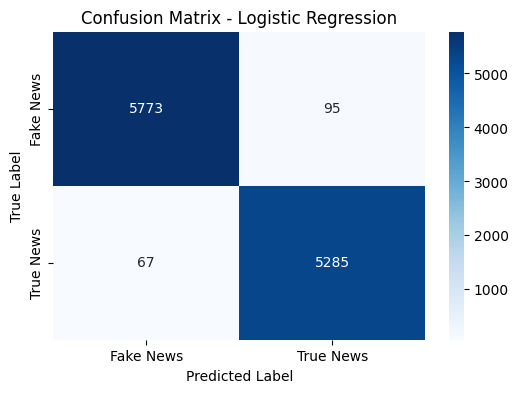

In [111]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [112]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

DecisionTreeClassifier()

In [113]:
pred_dt = DT.predict(xv_test)

In [114]:
DT.score(xv_test, y_test)

0.9950980392156863

In [115]:
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5868
           1       0.99      1.00      0.99      5352

    accuracy                           1.00     11220
   macro avg       1.00      1.00      1.00     11220
weighted avg       1.00      1.00      1.00     11220



### Confusion Matrix for Decision Tree
Now, let's visualize the performance of the Decision Tree model using a confusion matrix.

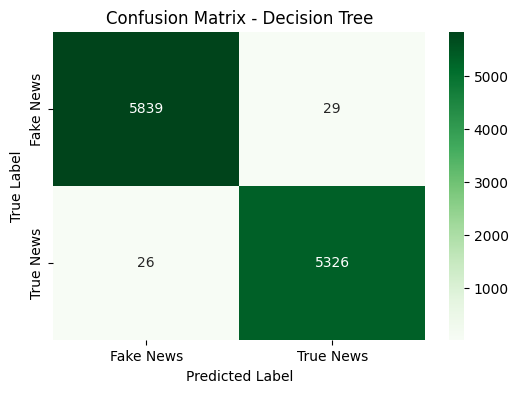

In [116]:
cm_dt = confusion_matrix(y_test, pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [117]:
print([x for x in globals() if 'train'in x.lower()])

['train_test_split', 'z_train', 'y_train', 'xv_train']


In [118]:
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier(random_state=0)
GBC.fit(xv_train, y_train)

GradientBoostingClassifier(random_state=0)

In [119]:
predict_gbc = GBC.predict(xv_test)

In [120]:
GBC.score(xv_test, y_test)

0.9955436720142602

In [121]:
print(classification_report(y_test, predict_gbc))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5868
           1       0.99      1.00      1.00      5352

    accuracy                           1.00     11220
   macro avg       1.00      1.00      1.00     11220
weighted avg       1.00      1.00      1.00     11220



### Confusion Matrix for Gradient Boosting Classifier
Next, we visualize the performance of the Gradient Boosting Classifier using a confusion matrix.

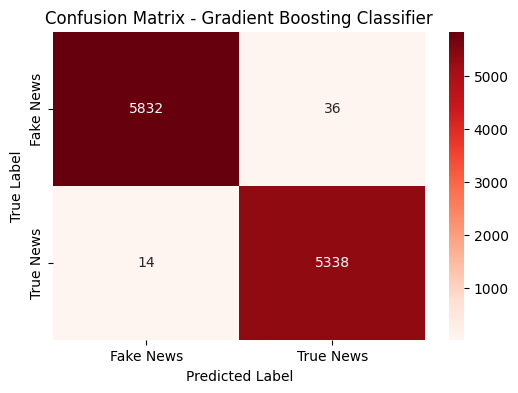

In [122]:
cm_gbc = confusion_matrix(y_test, predict_gbc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gbc, annot=True, fmt='d', cmap='Reds', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [123]:
from sklearn.ensemble import RandomForestClassifier
RFC = RandomForestClassifier(random_state=0)
RFC.fit(xv_train, y_train)

RandomForestClassifier(random_state=0)

In [124]:
predict_rfc = RFC.predict(xv_test)

In [125]:
RFC.score(xv_test, y_test)

0.984313725490196

In [126]:
print(classification_report(y_test, predict_rfc))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5868
           1       0.98      0.98      0.98      5352

    accuracy                           0.98     11220
   macro avg       0.98      0.98      0.98     11220
weighted avg       0.98      0.98      0.98     11220



### Confusion Matrix for Random Forest Classifier
Finally, let's look at the confusion matrix for the Random Forest Classifier.

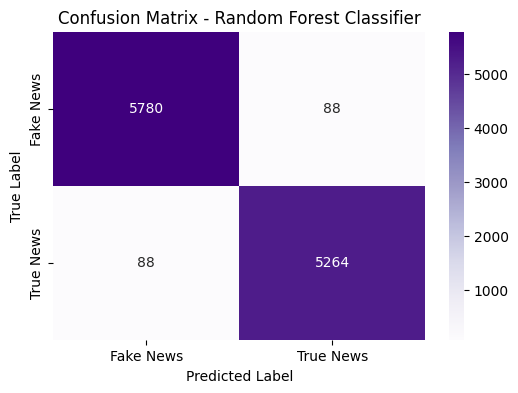

In [127]:
cm_rfc = confusion_matrix(y_test, predict_rfc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Purples', xticklabels=['Fake News', 'True News'], yticklabels=['Fake News', 'True News'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [135]:
def output_label(n):
    if n == 0:
        return "Fake News"
    elif n == 1:
        return "True News"

def manual_testing(news):
    testing_news = {"text":[news]}
    new_def_test = pd.DataFrame(testing_news)
    new_def_test["text"]= new_def_test["text"].apply(wordopt)
    new_x_test = new_def_test["text"]
    new_xv_test = vectorization.transform(new_x_test)
    pred_LR = LR.predict(new_xv_test)
    pred_DT = DT.predict(new_xv_test)
    pred_GBC = GBC.predict(new_xv_test)

    return print("\n\nLR Prediction: {} \nDT Prediction: {} \nGBC Prediction: {}".format(output_label(pred_LR[0]),
                                                                                                              output_label(pred_DT[0]),
                                                                                                              output_label(pred_GBC[0])))

In [134]:
news = input()
manual_testing(news)

WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional increases for non-defense “discretionary” spending on programs that support educati

In [130]:
data_fake.shape,data_true.shape

((23471, 5), (21407, 5))

In [136]:
news = input()
manual_testing(news)

Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even all

In [132]:
import pickle

pickle.dump(vectorization, open("vectorizer.pkl", "wb"))
pickle.dump(LR, open("lr_model.pkl", "wb"))
pickle.dump(DT, open("dt_model.pkl", "wb"))
pickle.dump(GBC, open("gbc_model.pkl", "wb"))
pickle.dump(RFC, open("rfc_model.pkl", "wb"))

print("All models saved successfully!")

All models saved successfully!
